# Lesson 19: SFR Enrichment and the Homogeneous-Flux Approximation

Lesson 16 replaced a fast-reactor pin cell by a volume-mixed homogeneous
material. Here we reconstruct its fuel, cladding, and sodium regions
explicitly, then test the physical assumption behind that replacement.
Every OpenMC model is built in this notebook; no course helper module or
hidden kernel state is required.

We will

1. build the Lesson 16 hexagonal SFR cell with explicit regions;
2. compare volume-average regional fluxes and spectra;
3. compare the direct production/absorption balance with the common-flux
   approximation of Eq. (4.8); and
4. find the U-235 enrichment that meets an assigned $k_\infty$ target.


## Model definition and controlled quantities

We retain the Lesson 16 dimensions and material inventories:

- fuel radius $r_f=0.4742$ cm;
- cladding outer radius $r_c=0.5419$ cm;
- nearest-neighbor pin pitch $P=1.1897$ cm;
- UO$_2$ at 10.5 g/cm$^3$, ODS steel at 7.13 g/cm$^3$, and sodium at
  0.837 g/cm$^3$.

The unit-height hexagonal prism has reflective lateral and axial
boundaries, so there is no leakage. All materials are held at 294 K to
isolate composition. The variable

$$
\widetilde e=\frac{N_{235}}{N_{235}+N_{238}}
$$

is the **U-235 atom fraction among uranium atoms**. We add U-235 and U-238
explicitly so that this basis is not confused with the weight-percent
convention of `Material.add_element(..., enrichment=...)`. Lesson 16 used
15 weight%; below, we convert that value to its atom-fraction equivalent.

To connect the infinite lattice to an illustrative finite-system target,
assume $P_{NL}=0.90$. Criticality would then require

$$k_\infty^*=\frac{1}{P_{NL}}=1.111\ldots.$$


In [1]:
import os
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import openmc
import pandas as pd

cross_sections = os.environ.get("OPENMC_CROSS_SECTIONS")
if not cross_sections or not Path(cross_sections).is_file():
    raise RuntimeError(
        "Set OPENMC_CROSS_SECTIONS to an installed OpenMC "
        "continuous-energy cross_sections.xml file."
    )
openmc.config["cross_sections"] = cross_sections

REGION_NAMES = ("fuel", "cladding", "coolant")

PITCH = 1.1897       # cm, nearest-neighbor pin pitch
FUEL_RADIUS = 0.4742 # cm
CLAD_RADIUS = 0.5419 # cm
CELL_HEIGHT = 1.0    # cm
HEX_SIDE = PITCH / np.sqrt(3.0)
CELL_AREA = np.sqrt(3.0) * PITCH**2 / 2.0

VOLUMES = np.array(
    [
        np.pi * FUEL_RADIUS**2 * CELL_HEIGHT,
        np.pi * (CLAD_RADIUS**2 - FUEL_RADIUS**2) * CELL_HEIGHT,
        (CELL_AREA - np.pi * CLAD_RADIUS**2) * CELL_HEIGHT,
    ]
)
VOLUME_FRACTIONS = VOLUMES / VOLUMES.sum()

U235_MASS = openmc.data.atomic_mass("U235")
U238_MASS = openmc.data.atomic_mass("U238")


def uranium_atom_fraction_from_weight_fraction(weight_fraction):
    n_235 = weight_fraction / U235_MASS
    n_238 = (1.0 - weight_fraction) / U238_MASS
    return n_235 / (n_235 + n_238)


def uranium_weight_fraction_from_atom_fraction(atom_fraction):
    m_235 = atom_fraction * U235_MASS
    m_238 = (1.0 - atom_fraction) * U238_MASS
    return m_235 / (m_235 + m_238)


LESSON16_ENRICHMENT_WEIGHT_FRACTION = 0.15
LESSON16_ENRICHMENT_ATOM_FRACTION = (
    uranium_atom_fraction_from_weight_fraction(
        LESSON16_ENRICHMENT_WEIGHT_FRACTION
    )
)

TEMPERATURE = 294.0  # K
SPECTRUM_EDGES = np.geomspace(1.0e2, 2.0e7, 121)  # eV
SPECTRUM_CENTERS = np.sqrt(SPECTRUM_EDGES[:-1] * SPECTRUM_EDGES[1:])
DELTA_U = np.log(SPECTRUM_EDGES[1:] / SPECTRUM_EDGES[:-1])

NONLEAKAGE_PROBABILITY = 0.90
TARGET_K_INFINITY = 1.0 / NONLEAKAGE_PROBABILITY

CLADDING_COMPOSITION = {
    "C": 3.5740e-4,
    "O": 3.9924e-4,
    "Ti": 5.3824e-4,
    "Cr": 1.7753e-2,
    "Fe": 5.3872e-2,
    "Ni": 3.6588e-4,
    "Mn": 2.3441e-4,
    "P": 2.7718e-5,
    "Al": 9.1482e-3,
    "Co": 2.1852e-4,
    "Cu": 1.0135e-4,
    "Y": 2.6616e-4,
}

PURPLE = "#512888"
ORANGE = "#CA7C1B"
TEAL = "#008080"


## 1. Build and run one heterogeneous SFR cell

`build_sfr_model` creates fresh materials, surfaces, cells, settings, and
tallies for each enrichment. The one-group tally has a `CellFilter` and
scores `flux`, `absorption`, and `nu-fission`. A separate fine-energy
flux tally is optional because the enrichment sweep only needs integrated
rates.

OpenMC's cell-filtered flux is integrated over each cell. Therefore, the
regional quantity to compare is $\Phi^r/V^r$, not the three raw tally
values.


In [2]:
def build_sfr_model(
    *,
    enrichment=LESSON16_ENRICHMENT_ATOM_FRACTION,
    particles=1600,
    batches=50,
    inactive=10,
    seed=19001,
    include_spectrum=False,
):
    '''Build the explicit-region Lesson 16 SFR unit cell.'''
    if not 0.0 < enrichment < 1.0:
        raise ValueError("enrichment must be an atom fraction in (0, 1)")
    if not 0 < inactive < batches:
        raise ValueError("require 0 < inactive < batches")

    fuel = openmc.Material(name="UO2 fuel")
    fuel.add_nuclide("U235", enrichment)
    fuel.add_nuclide("U238", 1.0 - enrichment)
    fuel.add_element("O", 2.0)
    fuel.set_density("g/cm3", 10.5)
    fuel.temperature = TEMPERATURE

    cladding = openmc.Material(name="ODS steel cladding")
    for element, amount in CLADDING_COMPOSITION.items():
        cladding.add_element(element, amount, "ao")
    cladding.set_density("g/cm3", 7.13)
    cladding.temperature = TEMPERATURE

    coolant = openmc.Material(name="sodium coolant")
    coolant.add_nuclide("Na23", 1.0)
    coolant.set_density("g/cm3", 0.837)
    coolant.temperature = TEMPERATURE

    fuel_surface = openmc.ZCylinder(r=FUEL_RADIUS)
    clad_surface = openmc.ZCylinder(r=CLAD_RADIUS)
    outer_surface = openmc.model.HexagonalPrism(
        edge_length=HEX_SIDE,
        orientation="x",
        boundary_type="reflective",
    )
    z_min = openmc.ZPlane(z0=-CELL_HEIGHT / 2.0, boundary_type="reflective")
    z_max = openmc.ZPlane(z0=+CELL_HEIGHT / 2.0, boundary_type="reflective")
    axial_region = +z_min & -z_max
    prism = -outer_surface & axial_region

    cells = (
        openmc.Cell(
            name="fuel", fill=fuel, region=-fuel_surface & axial_region
        ),
        openmc.Cell(
            name="cladding",
            fill=cladding,
            region=+fuel_surface & -clad_surface & axial_region,
        ),
        openmc.Cell(
            name="coolant", fill=coolant, region=+clad_surface & prism
        ),
    )
    for cell, volume in zip(cells, VOLUMES, strict=True):
        cell.volume = float(volume)

    settings = openmc.Settings(run_mode="eigenvalue")
    settings.batches = int(batches)
    settings.inactive = int(inactive)
    settings.particles = int(particles)
    settings.seed = int(seed)
    settings.source = openmc.IndependentSource(
        space=openmc.stats.Point((0.0, 0.0, 0.0)),
        angle=openmc.stats.Isotropic(),
        energy=openmc.stats.Discrete([2.0e6], [1.0]),
    )
    settings.temperature = {"method": "interpolation"}

    cell_filter = openmc.CellFilter(cells)
    rates = openmc.Tally(name="regional one-group rates")
    rates.filters = [cell_filter]
    rates.scores = ["flux", "absorption", "nu-fission"]
    tallies = [rates]

    if include_spectrum:
        spectrum = openmc.Tally(name="regional spectrum")
        spectrum.filters = [
            cell_filter,
            openmc.EnergyFilter(SPECTRUM_EDGES),
        ]
        spectrum.scores = ["flux"]
        tallies.append(spectrum)

    model = openmc.Model(
        geometry=openmc.Geometry(cells),
        materials=openmc.Materials([fuel, cladding, coolant]),
        settings=settings,
        tallies=openmc.Tallies(tallies),
    )
    return model


def run_case(*, include_spectrum=False, **model_parameters):
    '''Run one isolated case and reduce its regional tally results.'''
    model = build_sfr_model(
        include_spectrum=include_spectrum, **model_parameters
    )
    with tempfile.TemporaryDirectory(prefix="ne630_lesson19_") as run_dir:
        statepoint_path = model.run(cwd=run_dir, output=False)
        with openmc.StatePoint(statepoint_path) as statepoint:
            keff = statepoint.keff
            rates = statepoint.get_tally(name="regional one-group rates")
            flux = rates.get_values(
                scores=["flux"], value="mean"
            ).ravel().copy()
            flux_std = rates.get_values(
                scores=["flux"], value="std_dev"
            ).ravel().copy()
            absorption = rates.get_values(
                scores=["absorption"], value="mean"
            ).ravel().copy()
            production = rates.get_values(
                scores=["nu-fission"], value="mean"
            ).ravel().copy()

            spectrum_flux = None
            if include_spectrum:
                spectrum = statepoint.get_tally(name="regional spectrum")
                spectrum_flux = spectrum.get_values(
                    scores=["flux"], value="mean"
                ).reshape(len(REGION_NAMES), len(SPECTRUM_CENTERS)).copy()

    volume_average_flux = flux / VOLUMES
    cell_average_flux = flux.sum() / VOLUMES.sum()
    relative_flux = volume_average_flux / cell_average_flux

    sigma_a = absorption / flux
    nu_sigma_f = production / flux
    k_uniform_flux = np.dot(VOLUMES, nu_sigma_f) / np.dot(VOLUMES, sigma_a)
    production_over_absorption = production.sum() / absorption.sum()
    common_flux_bias = k_uniform_flux / production_over_absorption - 1.0

    result = {
        "enrichment": model_parameters.get(
            "enrichment", LESSON16_ENRICHMENT_ATOM_FRACTION
        ),
        "keff": float(keff.n),
        "sigma_k": float(keff.s),
        "B/A": production_over_absorption,
        "uniform-flux k": k_uniform_flux,
        "common-flux bias vs B/A": common_flux_bias,
        "flux max/min": volume_average_flux.max() / volume_average_flux.min(),
        "max |flux/cell average - 1|": np.max(np.abs(relative_flux - 1.0)),
        "integrated flux": flux,
        "flux relative uncertainty": flux_std / flux,
        "volume-average flux": volume_average_flux,
        "relative flux": relative_flux,
        "Sigma_a": sigma_a,
        "nuSigma_f": nu_sigma_f,
        "spectrum flux": spectrum_flux,
    }
    return result


In [3]:
geometry_table = pd.DataFrame(
    {
        "volume [cm3 per cm height]": VOLUMES,
        "volume fraction": VOLUME_FRACTIONS,
    },
    index=pd.Index(REGION_NAMES, name="region"),
)
np.testing.assert_allclose(VOLUMES.sum(), CELL_AREA * CELL_HEIGHT)
geometry_table


,volume [cm3 per cm height],volume fraction
region,,
fuel,0.706436,0.576325
cladding,0.216110,0.176307
coolant,0.303214,0.247368


## 2. Test the region-wise flux assumption

Start at the Lesson 16 reference enrichment, 15 weight% U-235, after
converting it to the atom-fraction basis used here. The integrated
fluxes should differ because the cells have different
volumes. The ratios in the last column compare $\Phi^r/V^r$ with the
whole-cell volume-average flux. Values near one support the approximation
$\phi_f\simeq\phi_{st}\simeq\phi_c$.

The scalar summary reports both the observed regional spread and the
individual flux-tally relative uncertainties. OpenMC does not provide the
covariance needed for a formal uncertainty on their ratios here. If those
quantities are comparable, the defensible conclusion is that no regional
difference is resolved at this calculation's precision.


In [4]:
baseline = run_case(
    enrichment=LESSON16_ENRICHMENT_ATOM_FRACTION,
    particles=3500,
    batches=70,
    inactive=15,
    seed=19015,
    include_spectrum=True,
)

regional_flux_table = pd.DataFrame(
    {
        "volume [cm3]": VOLUMES,
        "integrated flux Phi": baseline["integrated flux"],
        "volume-average flux Phi/V": baseline["volume-average flux"],
        "relative tally uncertainty": baseline["flux relative uncertainty"],
        "(Phi/V) / cell average": baseline["relative flux"],
    },
    index=pd.Index(REGION_NAMES, name="region"),
)
regional_flux_table


,volume [cm3],integrated flux Phi,volume-average flux Phi/V,relative tally uncertainty,(Phi/V) / cell average
region,,,,,
fuel,0.706436,70.629640,99.980204,0.001830,0.999593
cladding,0.216110,21.625719,100.068080,0.001862,1.000471
coolant,0.303214,30.346328,100.082210,0.001868,1.000613


In [5]:
pd.Series(
    {
        "OpenMC keff": baseline["keff"],
        "OpenMC sigma_k": baseline["sigma_k"],
        "direct production/absorption B/A": baseline["B/A"],
        "Eq. (4.8) common-flux reconstruction": baseline["uniform-flux k"],
        "common-flux reconstruction / B/A - 1":
            baseline["common-flux bias vs B/A"],
        "largest/smallest regional average flux": baseline["flux max/min"],
        "maximum regional deviation from cell average":
            baseline["max |flux/cell average - 1|"],
        "largest individual flux relative uncertainty":
            baseline["flux relative uncertainty"].max(),
    },
    name="Lesson 16 reference: 15 weight% U-235",
)


OpenMC keff                                     1.278252
OpenMC sigma_k                                  0.001459
direct production/absorption B/A                1.273674
Eq. (4.8) common-flux reconstruction            1.273692
common-flux reconstruction / B/A - 1            0.000015
largest/smallest regional average flux          1.001020
maximum regional deviation from cell average    0.000613
largest individual flux relative uncertainty    0.001868
Name: Lesson 16 reference: 15 weight% U-235, dtype: float64

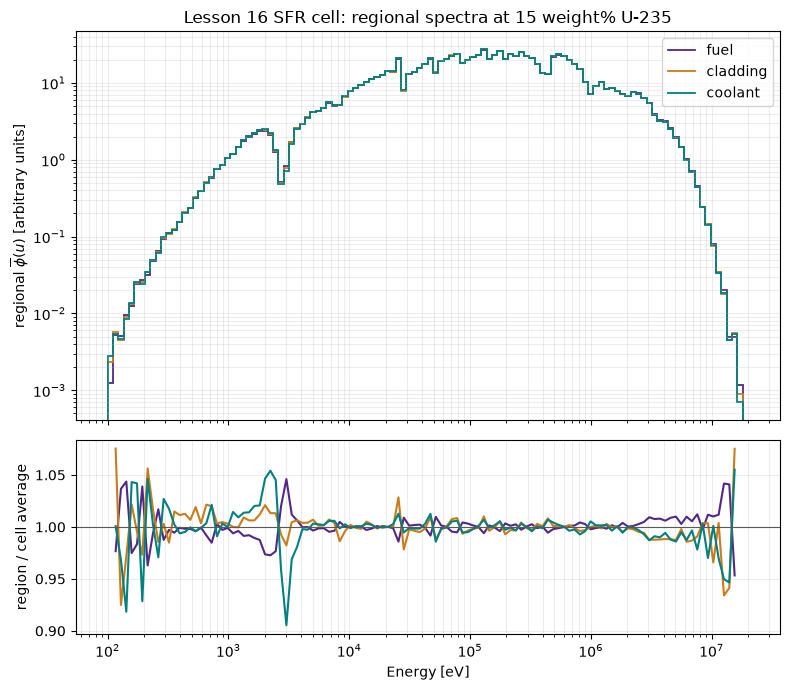

In [6]:
spectrum_per_lethargy = (
    baseline["spectrum flux"] / VOLUMES[:, None] / DELTA_U
)
cell_spectrum = (
    baseline["spectrum flux"].sum(axis=0) / VOLUMES.sum() / DELTA_U
)
reliable = cell_spectrum > 1.0e-4 * cell_spectrum.max()

fig, axes = plt.subplots(
    2, 1, figsize=(8, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]}
)
colors = (PURPLE, ORANGE, TEAL)
for region, spectrum, color in zip(
    REGION_NAMES, spectrum_per_lethargy, colors, strict=True
):
    axes[0].stairs(
        spectrum,
        SPECTRUM_EDGES,
        label=region,
        color=color,
        linewidth=1.3,
    )
    ratio = np.full_like(spectrum, np.nan)
    ratio[reliable] = spectrum[reliable] / cell_spectrum[reliable]
    axes[1].plot(SPECTRUM_CENTERS, ratio, color=color, label=region)

axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_ylabel(r"regional $\overline{\phi}(u)$ [arbitrary units]")
axes[0].set_title("Lesson 16 SFR cell: regional spectra at 15 weight% U-235")
axes[0].legend()
axes[1].axhline(1.0, color="0.35", linewidth=0.8)
axes[1].set_xscale("log")
axes[1].set_xlabel("Energy [eV]")
axes[1].set_ylabel("region / cell average")
for ax in axes:
    ax.grid(which="both", alpha=0.22)
fig.tight_layout();


The top panel preserves the common eigenvalue-source normalization and
divides only by volume and lethargy width, so vertical agreement is a
genuine magnitude comparison. The ratio panel exposes smaller spectral
differences that a one-group number can hide; bins deep in the sampled
tails are suppressed rather than interpreted as physics.

Using the measured region-specific effective cross sections, the exact
rate balance is

$$
\frac{B}{A}=\frac{\sum_r V_r\overline\phi_r
\overline{\nu\Sigma_f}^{,r}}
{\sum_r V_r\overline\phi_r\overline\Sigma_a^{,r}}.
$$

Setting all $\overline\phi_r$ equal gives the Lesson 16 common-flux
reconstruction. Its difference from $B/A$ isolates this approximation;
the remaining difference from `keff` can include Monte Carlo uncertainty
and nonfission neutron multiplication omitted by the simple balance.


## 3. Scan U-235 enrichment

Each point below is a fresh heterogeneous transport calculation. Changing
enrichment changes both number densities and the spectrum used to form
effective cross sections, so this is not merely the fixed-spectrum
algebra of Eq. (4.16). We retain `keff` uncertainty and also track the
regional-flux spread across the scan.


In [7]:
ENRICHMENTS = np.array([0.05, 0.08, 0.11, 0.14, 0.17, 0.20])

sweep_rows = []
for index, enrichment in enumerate(ENRICHMENTS):
    result = run_case(
        enrichment=enrichment,
        particles=1800,
        batches=55,
        inactive=10,
        seed=19100 + index,
    )
    sweep_rows.append(
        {
            key: result[key]
            for key in (
                "enrichment",
                "keff",
                "sigma_k",
                "B/A",
                "uniform-flux k",
                "common-flux bias vs B/A",
                "flux max/min",
                "max |flux/cell average - 1|",
            )
        }
    )
    print(
        f"e={100.0 * enrichment:5.1f} atom%  "
        f"keff={result['keff']:.5f} +/- {result['sigma_k']:.5f}  "
        f"flux max/min={result['flux max/min']:.4f}"
    )

sweep = pd.DataFrame(sweep_rows)
sweep.assign(**{"enrichment [atom% U-235]": 100.0 * sweep["enrichment"]})[
    [
        "enrichment [atom% U-235]",
        "keff",
        "sigma_k",
        "B/A",
        "uniform-flux k",
        "common-flux bias vs B/A",
        "flux max/min",
        "max |flux/cell average - 1|",
    ]
]


e=  5.0 atom%  keff=0.75807 +/- 0.00176  flux max/min=1.0019
e=  8.0 atom%  keff=0.95683 +/- 0.00165  flux max/min=1.0014
e= 11.0 atom%  keff=1.11344 +/- 0.00236  flux max/min=1.0007
e= 14.0 atom%  keff=1.23954 +/- 0.00267  flux max/min=1.0003
e= 17.0 atom%  keff=1.33735 +/- 0.00255  flux max/min=1.0003
e= 20.0 atom%  keff=1.42595 +/- 0.00232  flux max/min=1.0014


,enrichment [atom% U-235],keff,sigma_k,B/A,uniform-flux k,common-flux bias vs B/A,flux max/min,max |flux/cell average - 1|
0,5.0,0.758066,0.001759,0.758691,0.758731,0.000052,1.001876,0.001086
1,8.0,0.956826,0.001649,0.956755,0.956784,0.000031,1.001357,0.000886
2,11.0,1.113444,0.002361,1.110507,1.110520,0.000012,1.000674,0.000401
3,14.0,1.239544,0.002668,1.231851,1.231857,0.000005,1.000300,0.000190
4,17.0,1.337350,0.002553,1.333097,1.333103,0.000005,1.000333,0.000267
5,20.0,1.425953,0.002316,1.420247,1.420268,0.000015,1.001400,0.000871


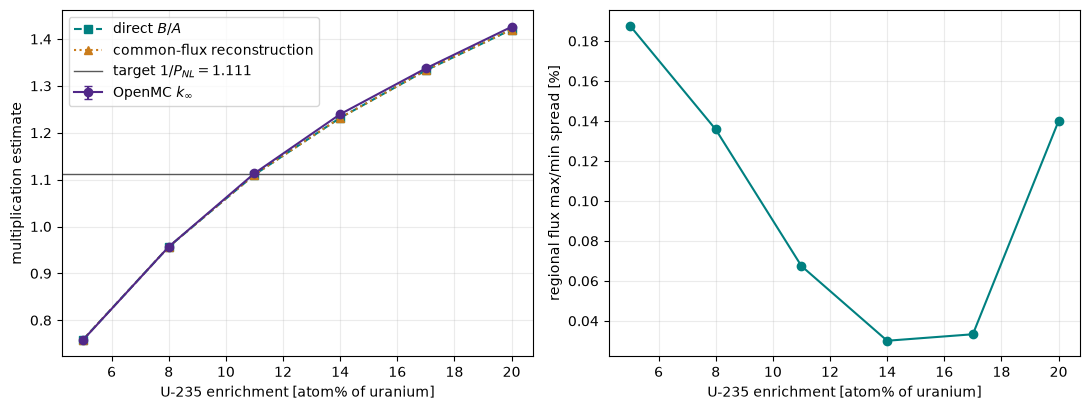

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
enrichment_percent = 100.0 * sweep["enrichment"]

axes[0].errorbar(
    enrichment_percent,
    sweep["keff"],
    yerr=sweep["sigma_k"],
    marker="o",
    capsize=3,
    color=PURPLE,
    label=r"OpenMC $k_\infty$",
)
axes[0].plot(
    enrichment_percent,
    sweep["B/A"],
    "s--",
    color=TEAL,
    label="direct $B/A$",
)
axes[0].plot(
    enrichment_percent,
    sweep["uniform-flux k"],
    "^:",
    color=ORANGE,
    label="common-flux reconstruction",
)
axes[0].axhline(
    TARGET_K_INFINITY,
    color="0.35",
    linewidth=1.0,
    label=rf"target $1/P_{{NL}}={TARGET_K_INFINITY:.3f}$",
)
axes[0].set_xlabel("U-235 enrichment [atom% of uranium]")
axes[0].set_ylabel("multiplication estimate")
axes[0].legend()

axes[1].plot(
    enrichment_percent,
    100.0 * (sweep["flux max/min"] - 1.0),
    "o-",
    color=TEAL,
)
axes[1].set_xlabel("U-235 enrichment [atom% of uranium]")
axes[1].set_ylabel("regional flux max/min spread [%]")
for ax in axes:
    ax.grid(alpha=0.25)
fig.tight_layout();


## 4. Estimate and verify the target enrichment

Use only the two simulated points that bracket the target. Linear
interpolation is adequate for proposing a confirmation run; it does not
claim that $k_\infty(\widetilde e)$ is globally linear. The confirmation
calculation uses more histories and an independent random seed.


In [9]:
residual = sweep["keff"].to_numpy() - TARGET_K_INFINITY
crossing_indices = np.flatnonzero(residual[:-1] * residual[1:] <= 0.0)
if crossing_indices.size != 1:
    raise RuntimeError(
        "The enrichment scan must contain exactly one target bracket."
    )

lower_index = int(crossing_indices[0])
lower = sweep.iloc[lower_index]
upper = sweep.iloc[lower_index + 1]
local_slope = (
    (upper["keff"] - lower["keff"])
    / (upper["enrichment"] - lower["enrichment"])
)
estimated_enrichment = lower["enrichment"] + (
    TARGET_K_INFINITY - lower["keff"]
) / local_slope

confirmation = run_case(
    enrichment=float(estimated_enrichment),
    particles=5000,
    batches=90,
    inactive=15,
    seed=19919,
)

pd.Series(
    {
        "interpolated enrichment [atom% U-235]":
            100.0 * estimated_enrichment,
        "interpolated enrichment [weight% U-235]":
            100.0
            * uranium_weight_fraction_from_atom_fraction(
                estimated_enrichment
            ),
        "confirmation keff": confirmation["keff"],
        "confirmation sigma_k": confirmation["sigma_k"],
        "target k-infinity": TARGET_K_INFINITY,
        "P_NL * confirmation keff":
            NONLEAKAGE_PROBABILITY * confirmation["keff"],
        "confirmation B/A": confirmation["B/A"],
        "confirmation common-flux k": confirmation["uniform-flux k"],
        "confirmation regional flux max/min": confirmation["flux max/min"],
    },
    name="target-enrichment check",
)


interpolated enrichment [atom% U-235]      10.955305
interpolated enrichment [weight% U-235]    10.831916
confirmation keff                           1.108110
confirmation sigma_k                        0.001013
target k-infinity                           1.111111
P_NL * confirmation keff                    0.997299
confirmation B/A                            1.107667
confirmation common-flux k                  1.107683
confirmation regional flux max/min          1.001025
Name: target-enrichment check, dtype: float64

## Interpretation and limits

1. Compare the raw integrated fluxes with their volume-normalized values.
   Why would the raw values give the wrong answer about spatial uniformity?
2. Quantify both the one-group regional spread and the energy-dependent
   departures in the ratio plot. “Similar in magnitude” does not mean
   identical at every energy. Compare the one-group spread with the tally
   uncertainty before deciding whether a difference is resolved.
3. Compare the common-flux reconstruction, direct $B/A$, and `keff` over
   the enrichment scan. Is the Lesson 16 homogenization assumption useful
   at the accuracy supported by these Monte Carlo calculations?
4. Report the target enrichment only to precision justified by the local
   slope, grid spacing, and `keff` uncertainty.

This is an infinite, fresh-fuel, one-pin lattice. The assumed
non-leakage probability is imposed after the unit-cell calculation; a
full-core design must determine leakage and include depletion, control,
thermal limits, structural inventories outside the pin cell, and safety
coefficients.
